# Question 9: Image Segmentation


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler

## 1. Setup and Feature Engineering

In [3]:
def create_feature_vector(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape

    y_coords, x_coords = np.mgrid[:h, :w]
    
    y_norm = y_coords / h
    x_norm = x_coords / w
    
    img_norm = img / 255.0
    
    features = np.dstack((y_norm, x_norm, img_norm)).reshape(-1, 5)
    
    return features, img.shape, img

def visualize_segmentation(original_img, labels, k, title):
    segmented_img = labels.reshape(original_img.shape[:2])
    plt.imshow(segmented_img, cmap='viridis')
    plt.title(f"{title} (K={k})")
    plt.axis('off')

image_paths = ['data/image1.jpg', 'data/image2.jpg']
k_values = [2, 3, 4, 5]

## 2. Segmentation using K-Means Clustering

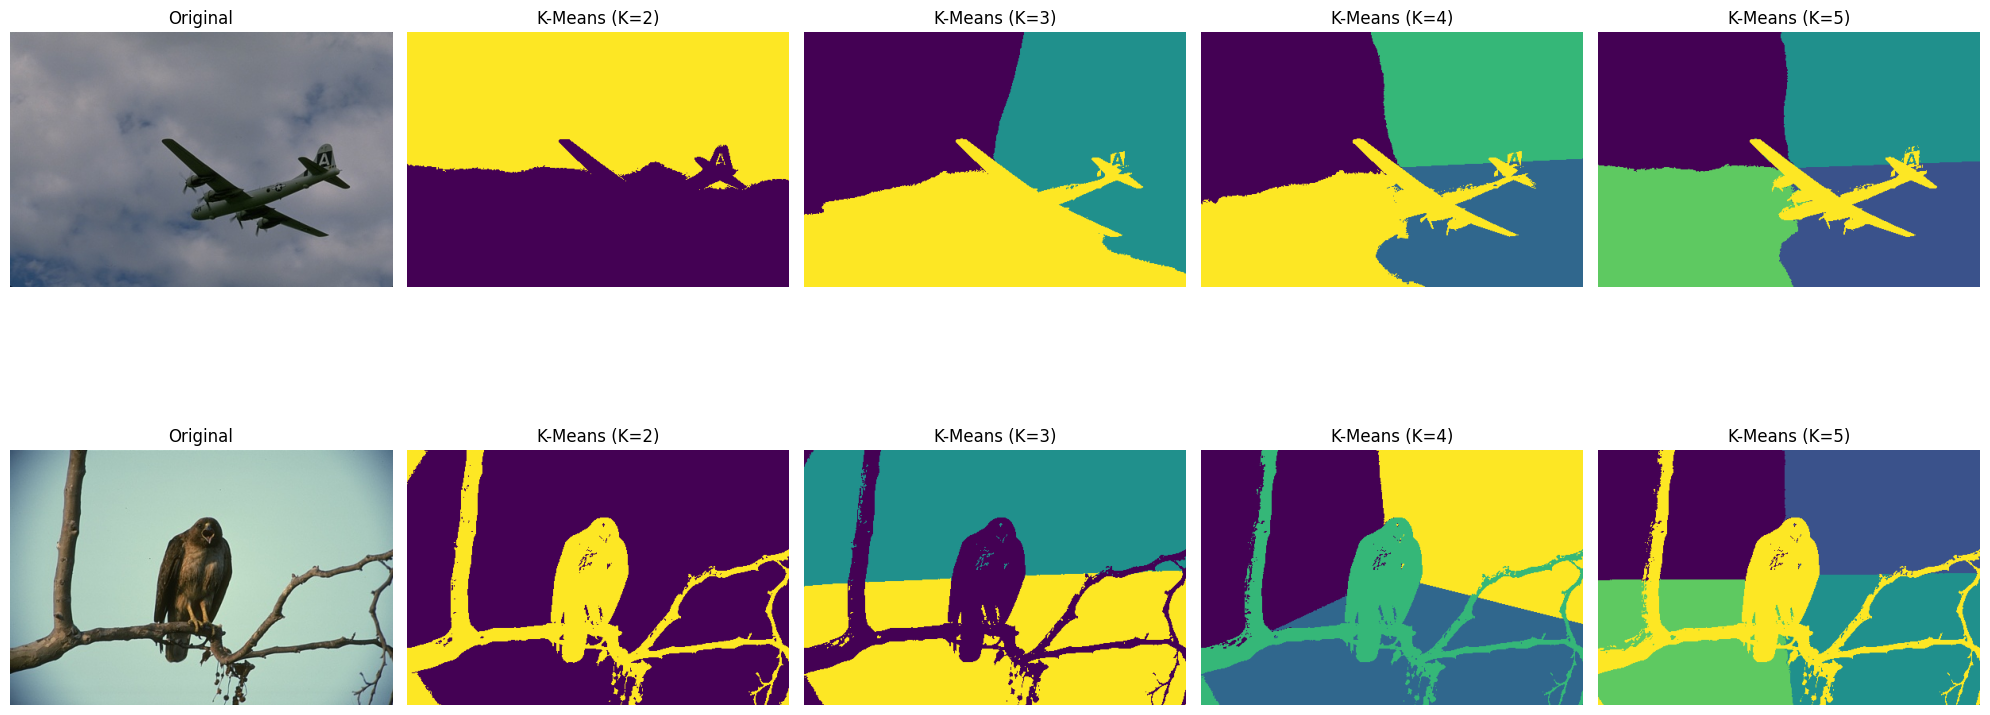

In [8]:
plt.figure(figsize=(20, 10))
plot_idx = 1

for img_path in image_paths:
    features, shape, original_img = create_feature_vector(img_path)
    
    plt.subplot(len(image_paths), len(k_values) + 1, plot_idx)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis('off')
    plot_idx += 1
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(features)
        
        plt.subplot(len(image_paths), len(k_values) + 1, plot_idx)
        visualize_segmentation(original_img, labels, k, "K-Means")
        plot_idx += 1

plt.tight_layout()
plt.show()

## 3. Segmentation using Gaussian Mixture Models (GMM)

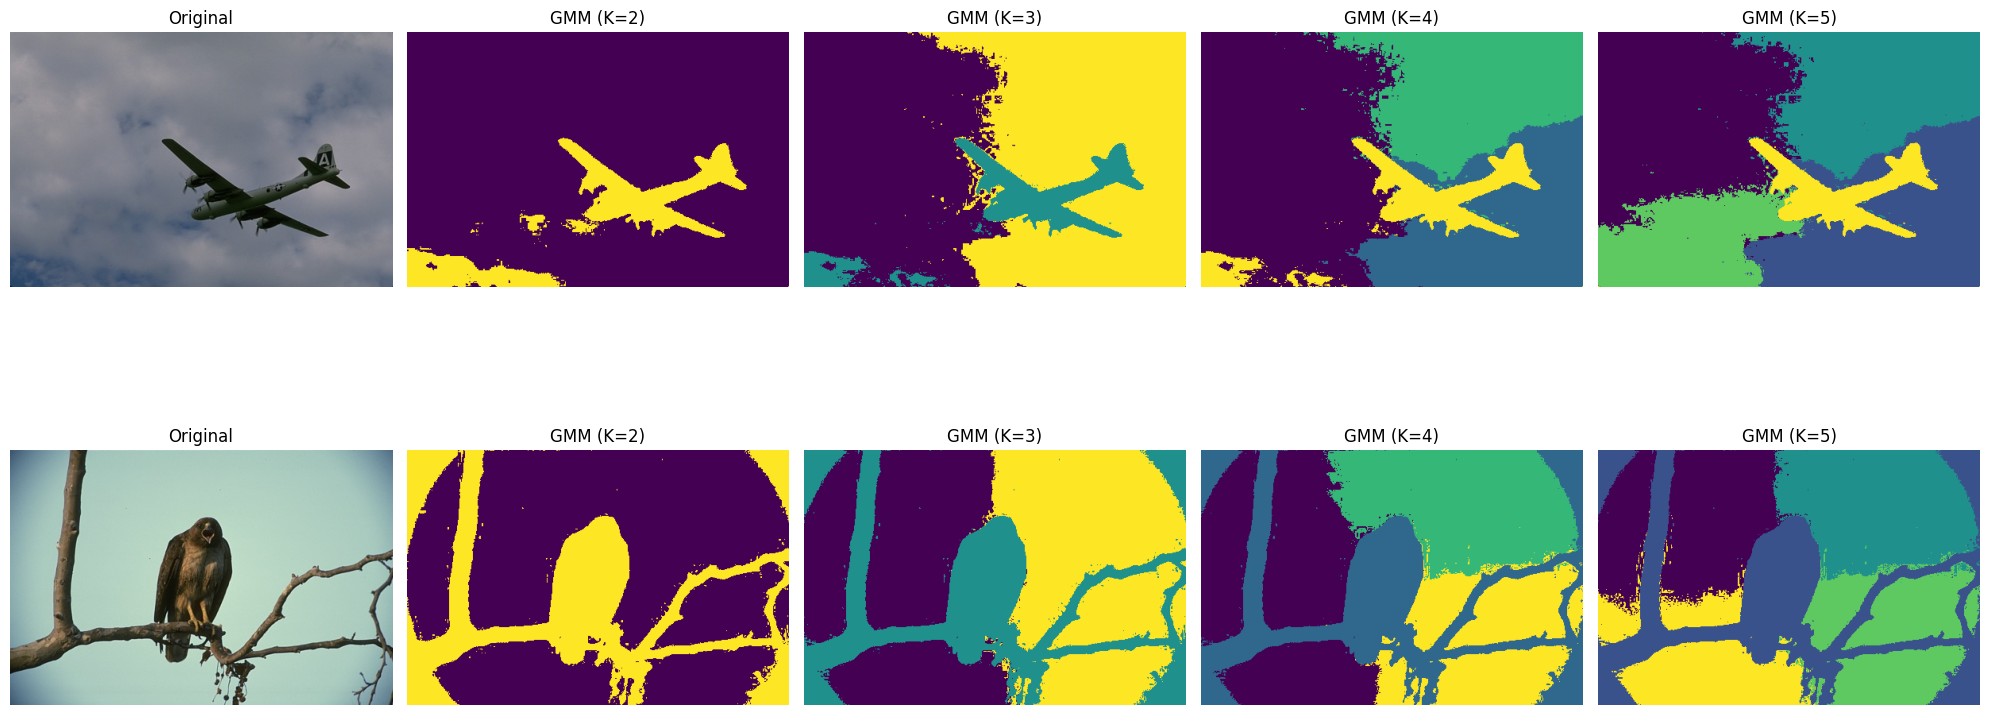

: 

In [ ]:
plt.figure(figsize=(20, 10))
plot_idx = 1

for img_path in image_paths:
    features, shape, original_img = create_feature_vector(img_path)
    
    plt.subplot(len(image_paths), len(k_values) + 1, plot_idx)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis('off')
    plot_idx += 1
    
    for k in k_values:
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        labels = gmm.fit_predict(features)
        
        plt.subplot(len(image_paths), len(k_values) + 1, plot_idx)
        visualize_segmentation(original_img, labels, k, "GMM")
        plot_idx += 1

plt.tight_layout()
plt.show()